# Landfall variant


Correlation matrix heatmap saved to 'figures' as PNG, PDF, and SVG.


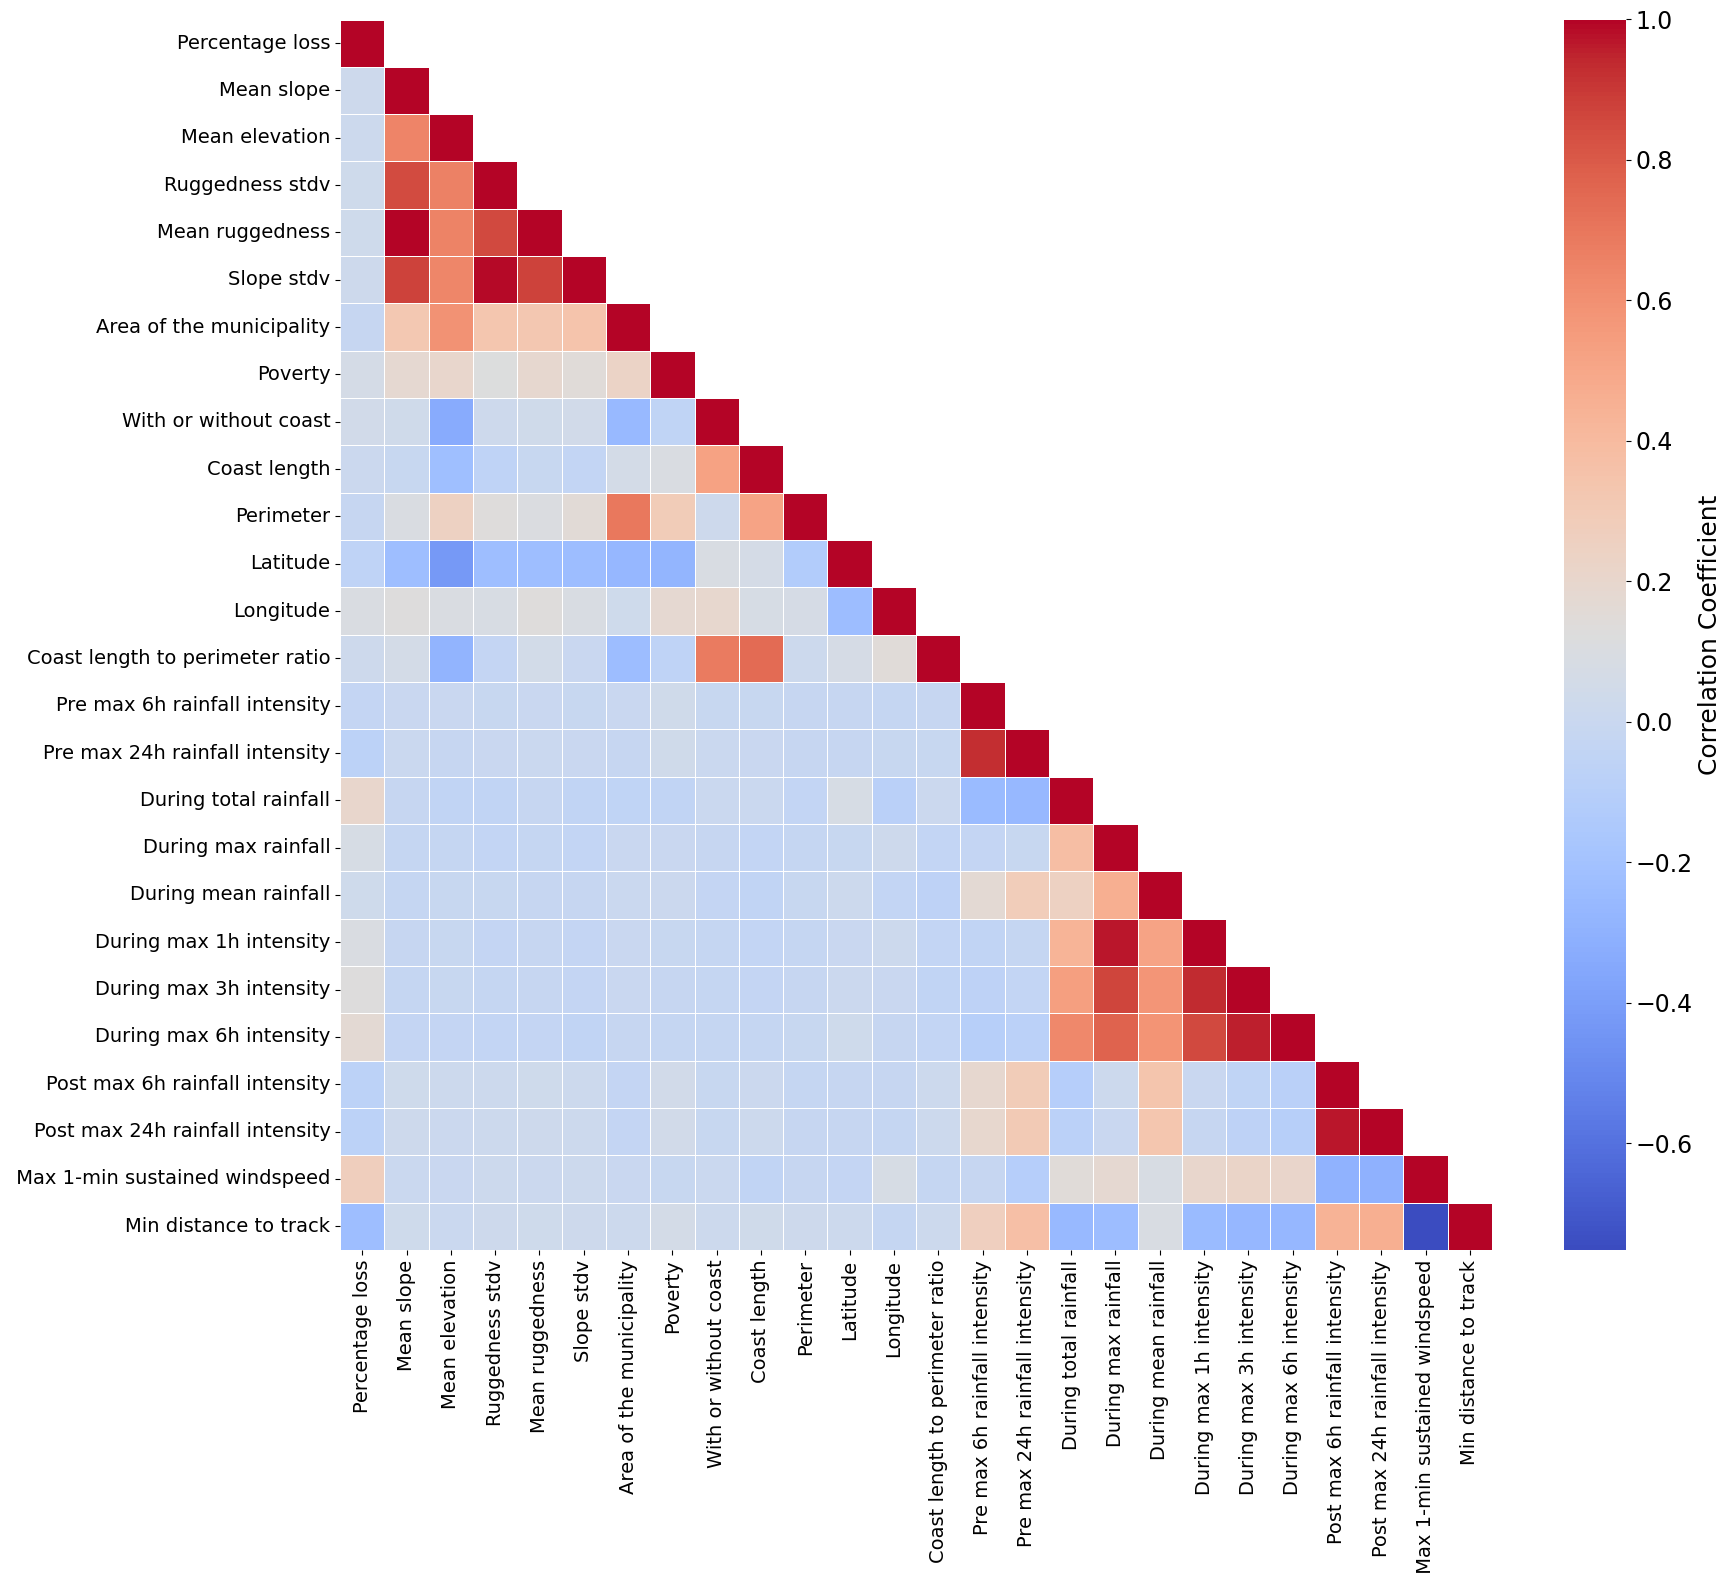

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np # For creating the mask
import os

# --- Configuration for Plot Aesthetics ---
LABEL_FONT_SIZE = 16 # For axis labels if added, but here primarily tick labels
TICK_LABEL_SIZE = 11 # Adjusted for potentially many labels
COLORBAR_LABEL_SIZE = 18

# --- Step 1: Load the data ---
file_path = 'restricted_data/combined_input_data/input_data_05_lf.xlsx'
try:
    df = pd.read_excel(file_path)
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please check the path.")
    exit()

# --- Step 2: Filter the data to include only samples where year < 2016 ---
df = df[df['year'] < 2016]

# --- Step 3: Define variables to exclude from the final plot ---
# These are columns that are non-independent or directly target-related
# and should not appear in the correlation matrix, but were not part of the
# list you provided for renaming.
variables_to_exclude_from_final_plot = [
    'mun_code', 'typhoon', 'area_affected', 'storm_id', 'year', 'reg_code',
    'prov_code', 'rice_area', 'damage_above_30', 'class_old', # Non-independent/Target related
]

# --- Step 4: Create the DataFrame with relevant variables for the heatmap ---
# Filter to keep only the columns that are present in your df and are not excluded.
# Then ensure the order matches the one you provided for renaming.
# We'll use the provided list as the definitive order.
columns_for_heatmap_order = [
    'perc_loss', 'mean_slope', 'mean_elevation_m', 'ruggedness_stdev',
    'mean_ruggedness', 'slope_stdev', 'area_km2', 'poverty_perc',
    'with_coast', 'coast_length', 'perimeter', 'glat', 'glon',
    'coast_peri_ratio', 'pre_max_6h', 'pre_max_24h', 'during_total_rainfall',
    'during_max_rainfall', 'during_mean_rainfall', 'during_max_1h_intensity',
    'during_max_3h_intensity', 'during_max_6h_intensity', 'post_max_6h',
    'post_max_24h', 'vmax', 'dis_track_min'
]

# Create the filtered DataFrame, selecting only the columns present in the source df
# and ensuring they are in the specified order.
df_filtered = df[columns_for_heatmap_order].copy()


# Drop rows with any NaN values in the selected columns to ensure correlation calculation is clean
df_filtered.dropna(inplace=True)

# --- Step 5: Define the mapping for column names to descriptive names ---
# IMPORTANT: Ensure the keys in this dictionary EXACTLY match the column names
# in your 'df_filtered' DataFrame.
renaming_map = {
    'perc_loss': 'Percentage loss',
    'mean_slope': 'Mean slope',
    'mean_elevation_m': 'Mean elevation',
    'ruggedness_stdev': 'Ruggedness stdv',
    'mean_ruggedness': 'Mean ruggedness',
    'slope_stdev': 'Slope stdv',
    'area_km2': 'Area of the municipality',
    'poverty_perc': 'Poverty',
    'with_coast': 'With or without coast',
    'coast_length': 'Coast length',
    'perimeter': 'Perimeter',
    'glat': 'Latitude',
    'glon': 'Longitude',
    'coast_peri_ratio': 'Coast length to perimeter ratio',
    'pre_max_6h': 'Pre max 6h rainfall intensity',
    'pre_max_24h': 'Pre max 24h rainfall intensity',
    'during_total_rainfall': 'During total rainfall',
    'during_max_rainfall': 'During max rainfall',
    'during_mean_rainfall': 'During mean rainfall',
    'during_max_1h_intensity': 'During max 1h intensity',
    'during_max_3h_intensity': 'During max 3h intensity',
    'during_max_6h_intensity': 'During max 6h intensity',
    'post_max_6h': 'Post max 6h rainfall intensity',
    'post_max_24h': 'Post max 24h rainfall intensity',
    'vmax': ' Max 1-min sustained windspeed',
    'dis_track_min': 'Min distance to track'
}

# Rename the columns in the DataFrame
df_filtered.rename(columns=renaming_map, inplace=True)


# --- Step 6: Calculate the correlation matrix ---
corr_matrix = df_filtered.corr()

# --- Step 7: Create a mask for the upper triangle to remove mirroring ---
# np.triu returns the upper triangle of an array. k=1 means excluding the diagonal.
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

# --- Step 8: Plot the correlation matrix heatmap for paper publication ---
plt.figure(figsize=(18, 16)) # Adjusted figure size for more variables

# Create the heatmap
sns.heatmap(corr_matrix,
            mask=mask, # Apply the mask to show only the lower triangle
            annot=False, # No numbers inside the boxes
            cmap='coolwarm', # Red for negative, Blue for positive, white for near zero
            linewidths=.5, # Adds lines between cells
            cbar_kws={'label': 'Correlation Coefficient'}) # Label for the colorbar

# Customize tick labels
plt.xticks(fontsize=TICK_LABEL_SIZE+3, rotation=90) # Rotate x-axis labels
plt.yticks(fontsize=TICK_LABEL_SIZE+3, rotation=0) # Keep y-axis labels horizontal

# Adjust colorbar label font size
cbar = plt.gca().collections[0].colorbar
cbar.set_label('Correlation Coefficient', fontsize=COLORBAR_LABEL_SIZE)
cbar.ax.tick_params(labelsize=TICK_LABEL_SIZE+6)

# Ensure a tight layout to minimize whitespace around the plot
plt.tight_layout()

# --- Step 9: Save the plot in multiple formats ---
output_dir = 'figures'
os.makedirs(output_dir, exist_ok=True) # Create 'figures' directory if it doesn't exist

filename_prefix = os.path.join(output_dir, "correlation_matrix_heatmap")
plt.savefig(f"{filename_prefix}.png", dpi=300, bbox_inches='tight') # High DPI for quality
plt.savefig(f"{filename_prefix}.pdf", bbox_inches='tight') # Vector format
plt.savefig(f"{filename_prefix}.svg", bbox_inches='tight') # Another vector format

print(f"Correlation matrix heatmap saved to '{output_dir}' as PNG, PDF, and SVG.")

plt.show()

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from ipywidgets import interact, widgets
from IPython.display import display
import os

# Set working directory
os.chdir("/home/jovyan/work/Typhoon_IBF_Rice_Damage_Model/")
cdir = os.getcwd()

# Step 1: Load the data
file_path = 'IBF_typhoon_model/data/restricted_data/combined_input_data/input_data_05.xlsx'
df = pd.read_excel(file_path)

# Step 2: Filter the data to include only samples where year < 2016
df = df[df['year'] < 2016]

# Step 3: Remove non-independent variables, but keep the target variable 'perc_loss'
non_independent_vars = ['mun_code', 'typhoon', 'area_affected', 'storm_id', 'year', 'reg_code',
                        'prov_code', 'rice_area', 'damage_above_30', 'class_old']

df_independent = df.drop(columns=non_independent_vars)

# Step 4: Remove specific variables as requested
variables_to_remove = [
    'lf_pre_max_6h',
    'lf_pre_max_24h',
    'lf_during_total_rainfall',
    'lf_during_max_rainfall',
    'lf_during_mean_rainfall',
    'lf_during_max_1h_intensity',
    'lf_during_max_3h_intensity',
    'lf_during_max_6h_intensity',
    'lf_post_max_6h',
    'lf_post_max_24h'
]

df_independent = df_independent.drop(columns=variables_to_remove)

# Step 5: Print the correlation table in the original order of variables as they appear in the Excel
corr_with_target = df_independent.corr()['perc_loss']
ordered_corr = corr_with_target.reindex(df_independent.columns)
print("Correlation between 'perc_loss' and independent variables in the original order:")
print(ordered_corr)

# Step 6: Define the function to update the plot
def update_plot(selected_vars):
    if selected_vars:
        selected_df = df_independent[list(selected_vars)]
        corr_matrix = selected_df.corr()
        
        plt.figure(figsize=(24, 20))
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f",annot_kws={"size": 14})

        plt.title('Correlation Matrix of Selected Variables', fontsize=20)
        plt.xticks(fontsize=14)
        plt.yticks(fontsize=14)
        plt.show()
    else:
        print("No variables selected.")

# Step 7: Create the widget for selecting variables with adjusted size
all_vars = df_independent.columns.tolist()
var_selector = widgets.SelectMultiple(
    options=all_vars,
    value=all_vars + ['perc_loss'],  # Include 'perc_loss' in the default selection
    description='Variables',
    disabled=False,
    layout=widgets.Layout(width='30%', height='300px')  # Adjust the width and height here
)

# Step 8: Display the interactive widget
interactive_plot = interact(update_plot, selected_vars=var_selector)
display(interactive_plot)


Correlation between 'perc_loss' and independent variables in the original order:
perc_loss                  1.000000
mean_slope                 0.021050
mean_elevation_m           0.012853
ruggedness_stdev           0.029272
mean_ruggedness            0.024224
slope_stdev                0.022589
area_km2                  -0.012645
poverty_perc               0.065105
with_coast                 0.038621
coast_length               0.012289
perimeter                 -0.010483
glat                      -0.053655
glon                       0.105162
coast_peri_ratio           0.020654
pre_max_6h                 0.020435
pre_max_24h               -0.007347
during_total_rainfall      0.184507
during_max_rainfall        0.086200
during_mean_rainfall       0.059326
during_max_1h_intensity    0.105277
during_max_3h_intensity    0.124127
during_max_6h_intensity    0.167042
post_max_6h               -0.018924
post_max_24h               0.005178
vmax                       0.244295
dis_track_min      

interactive(children=(SelectMultiple(description='Variables', index=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,…

<function __main__.update_plot(selected_vars)>

ruggedness_stdev, pre_max_6h, during_total_rainfall, post_max_6h

# Extent variant

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from ipywidgets import interact, widgets
from IPython.display import display
import os

# Set working directory
os.chdir("/home/jovyan/work/Typhoon_IBF_Rice_Damage_Model/")
cdir = os.getcwd()

# Step 1: Load the data
file_path = 'IBF_typhoon_model/data/restricted_data/combined_input_data/input_data_05_lf.xlsx'
df = pd.read_excel(file_path)

# Step 2: Filter the data to include only samples where year < 2016
df = df[df['year'] < 2016]

# Step 3: Remove non-independent variables, but keep the target variable 'perc_loss'
non_independent_vars = ['mun_code', 'typhoon', 'area_affected', 'storm_id', 'year', 'reg_code',
                        'prov_code', 'rice_area', 'damage_above_30', 'class_old']

df_independent = df.drop(columns=non_independent_vars)

# Step 4: Remove specific variables as requested
variables_to_remove = [
    'pre_max_6h',
    'pre_max_24h',
    'during_total_rainfall',
    'during_max_rainfall',
    'during_mean_rainfall',
    'during_max_1h_intensity',
    'during_max_3h_intensity',
    'post_max_6h',
    'post_max_24h'
]


df_independent = df_independent.drop(columns=variables_to_remove)

# Step 5: Print the correlation table in the original order of variables as they appear in the Excel
corr_with_target = df_independent.corr()['perc_loss']
ordered_corr = corr_with_target.reindex(df_independent.columns)
print("Correlation between 'perc_loss' and independent variables in the original order:")
print(ordered_corr)

# Step 6: Define the function to update the plot
def update_plot(selected_vars):
    if selected_vars:
        selected_df = df_independent[list(selected_vars)]
        corr_matrix = selected_df.corr()
        
        plt.figure(figsize=(24, 20))
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
        plt.title('Correlation Matrix of Selected Variables')
        plt.show()
    else:
        print("No variables selected.")

# Step 7: Create the widget for selecting variables with adjusted size
all_vars = df_independent.columns.tolist()
var_selector = widgets.SelectMultiple(
    options=all_vars,
    value=all_vars + ['perc_loss'],  # Include 'perc_loss' in the default selection
    description='Variables',
    disabled=False,
    layout=widgets.Layout(width='30%', height='300px')  # Adjust the width and height here
)

# Step 8: Display the interactive widget
interactive_plot = interact(update_plot, selected_vars=var_selector)
display(interactive_plot)


Correlation between 'perc_loss' and independent variables in the original order:
perc_loss                     1.000000
mean_slope                    0.021050
mean_elevation_m              0.012853
ruggedness_stdev              0.029272
mean_ruggedness               0.024224
slope_stdev                   0.022589
area_km2                     -0.012645
poverty_perc                  0.065105
with_coast                    0.038621
coast_length                  0.012289
perimeter                    -0.010483
glat                         -0.053655
glon                          0.105162
coast_peri_ratio              0.020654
lf_pre_max_6h                 0.122644
lf_pre_max_24h                0.070511
lf_during_total_rainfall      0.070114
lf_during_max_rainfall        0.048685
lf_during_mean_rainfall       0.070114
lf_during_max_1h_intensity    0.055529
lf_during_max_3h_intensity    0.070039
lf_during_max_6h_intensity    0.082611
lf_post_max_6h                0.081066
lf_post_max_24h       

interactive(children=(SelectMultiple(description='Variables', index=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,…

<function __main__.update_plot(selected_vars)>

ruggedness_stdev, lf_pre_max_6h, lf_during_max_6h_intensity, lf_post_max_24h